# Clustering

In [2]:
import pandas as pd

In [3]:
user_features = pd.read_csv("data/data_preprocessed/user_features_grouped1.csv")

In [4]:
user_features["group"].value_counts()

group
Not assigned               2017
VIPs                       1200
Long-Distance Travelers     790
Discount buyers             695
Quick Decision Makers       627
Long Stayers                230
Young Travelers             153
Family Travelers             70
Name: count, dtype: int64

In [5]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer,trips_per_session,total_spent,group
0,94883,F,True,False,usa,kansas city,MCI,51,2022,Missouri,...,1.000000,5354.8600,230.00,8.333333,1060.930335,8.042895,1.036111,0.250000,5584.8600,VIPs
1,101486,F,True,True,usa,tacoma,TCM,50,2022,Washington,...,3.333333,351.7425,2277.05,26.153846,2094.397252,2.379286,10.992308,0.230769,2628.7925,Long-Distance Travelers
2,101961,F,True,False,usa,boston,BOS,43,2022,Massachusetts,...,3.285714,1924.2330,2550.40,18.166667,2436.512974,8.049231,2.256944,0.583333,4474.6330,VIPs
3,106907,F,True,True,usa,miami,TNT,44,2022,Florida,...,6.000000,165.5100,2231.00,26.285714,2061.557769,3.142023,8.365858,0.142857,2396.5100,Long-Distance Travelers
4,118043,F,False,True,usa,los angeles,LAX,51,2022,California,...,5.500000,2339.2900,5811.00,16.153846,623.381115,4.274937,3.778733,0.384615,8150.2900,VIPs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,49,2023,California,...,1.000000,1122.1060,220.00,15.500000,609.885174,8.034557,1.929167,0.250000,1342.1060,Discount buyers
5778,785186,F,True,True,usa,little rock,LIT,44,2023,Arkansas,...,1.000000,353.3500,291.00,21.625000,263.178203,8.052754,2.685417,0.250000,644.3500,Not assigned
5779,792549,F,False,False,usa,kansas city,MCI,45,2023,Missouri,...,4.000000,1039.1700,136.80,14.250000,719.002463,8.000000,1.781250,0.500000,1175.9700,Not assigned
5780,811077,F,True,True,usa,knoxville,TYS,44,2023,Tennessee,...,6.000000,579.7900,852.00,13.125000,398.104421,7.944515,1.652083,0.125000,1431.7900,Not assigned


In [6]:
df_raw= user_features[user_features["group"] == "Not assigned"]

In [7]:
df_raw.isna().sum()

user_id                    0
gender                     0
married                    0
has_children               0
home_country               0
home_city                  0
home_airport               0
age                        0
sign_up_year               0
states                    70
num_session                0
num_trips                  0
num_flights                0
num_hotels                 0
booking_discount_rate    314
average_seats            397
average_checked_bags     397
average_seats_price      397
weekend_trip_ratio       344
average_nights           344
total_flight_cost        397
total_hotels_cost        344
avg_clicks                 0
avg_distance_user          0
clicks_per_min             0
avg_session_dauer          0
trips_per_session          0
total_spent              427
group                      0
dtype: int64

In [8]:
df_raw.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'sign_up_year', 'states',
       'num_session', 'num_trips', 'num_flights', 'num_hotels',
       'booking_discount_rate', 'average_seats', 'average_checked_bags',
       'average_seats_price', 'weekend_trip_ratio', 'average_nights',
       'total_flight_cost', 'total_hotels_cost', 'avg_clicks',
       'avg_distance_user', 'clicks_per_min', 'avg_session_dauer',
       'trips_per_session', 'total_spent', 'group'],
      dtype='str')

In [9]:
df = df_raw.drop(columns=['user_id', 'home_country', 'home_city', 'home_airport', 'states', 'sign_up_year', 'group'])

In [10]:
df

,gender,married,has_children,age,num_session,num_trips,num_flights,num_hotels,booking_discount_rate,average_seats,...,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer,trips_per_session,total_spent
5,F,False,True,45,11,4,4,4,0.000000,1.0,...,0.000000,3.000000,789.9600,1891.0,23.000000,0.000000,2.863280,8.032746,0.363636,2680.9600
12,F,False,True,26,11,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,21.909091,316.524720,1.844355,11.878996,0.000000,NaN
17,F,True,True,46,12,3,3,1,0.333333,1.0,...,0.000000,5.000000,1450.7475,240.0,13.000000,737.908120,8.020566,1.620833,0.250000,1690.7475
19,F,False,False,20,11,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,12.545455,0.000000,8.038835,1.560606,0.000000,NaN
20,M,True,False,30,11,3,3,3,0.000000,1.0,...,0.666667,1.333333,1802.7900,644.0,12.727273,916.235430,8.007626,1.589394,0.272727,2446.7900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5774,F,False,False,24,8,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,36.500000,795.942662,2.223068,16.418750,0.000000,NaN
5778,F,True,True,44,8,2,2,2,0.000000,1.0,...,1.000000,1.000000,353.3500,291.0,21.625000,263.178203,8.052754,2.685417,0.250000,644.3500
5779,F,False,False,45,8,4,4,1,0.000000,1.0,...,1.000000,4.000000,1039.1700,136.8,14.250000,719.002463,8.000000,1.781250,0.500000,1175.9700
5780,F,True,True,44,8,1,1,1,0.000000,1.0,...,0.000000,6.000000,579.7900,852.0,13.125000,398.104421,7.944515,1.652083,0.125000,1431.7900


kategorische Spalten umwandeln

In [11]:
df["gender"].value_counts()

gender
F    1790
M     223
O       4
Name: count, dtype: int64

In [12]:
df["gender"].map({"F":0, "M":1, "O":2})

5       0
12      0
17      0
19      0
20      1
       ..
5774    0
5778    0
5779    0
5780    0
5781    1
Name: gender, Length: 2017, dtype: int64

In [13]:
df["gender"] = df["gender"].map({"F":0, "M":1, "O":2})

In [14]:
df.shape

(2017, 22)

In [15]:
df

,gender,married,has_children,age,num_session,num_trips,num_flights,num_hotels,booking_discount_rate,average_seats,...,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer,trips_per_session,total_spent
5,0,False,True,45,11,4,4,4,0.000000,1.0,...,0.000000,3.000000,789.9600,1891.0,23.000000,0.000000,2.863280,8.032746,0.363636,2680.9600
12,0,False,True,26,11,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,21.909091,316.524720,1.844355,11.878996,0.000000,NaN
17,0,True,True,46,12,3,3,1,0.333333,1.0,...,0.000000,5.000000,1450.7475,240.0,13.000000,737.908120,8.020566,1.620833,0.250000,1690.7475
19,0,False,False,20,11,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,12.545455,0.000000,8.038835,1.560606,0.000000,NaN
20,1,True,False,30,11,3,3,3,0.000000,1.0,...,0.666667,1.333333,1802.7900,644.0,12.727273,916.235430,8.007626,1.589394,0.272727,2446.7900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5774,0,False,False,24,8,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,36.500000,795.942662,2.223068,16.418750,0.000000,NaN
5778,0,True,True,44,8,2,2,2,0.000000,1.0,...,1.000000,1.000000,353.3500,291.0,21.625000,263.178203,8.052754,2.685417,0.250000,644.3500
5779,0,False,False,45,8,4,4,1,0.000000,1.0,...,1.000000,4.000000,1039.1700,136.8,14.250000,719.002463,8.000000,1.781250,0.500000,1175.9700
5780,0,True,True,44,8,1,1,1,0.000000,1.0,...,0.000000,6.000000,579.7900,852.0,13.125000,398.104421,7.944515,1.652083,0.125000,1431.7900


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 2017 entries, 5 to 5781
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 2017 non-null   int64  
 1   married                2017 non-null   bool   
 2   has_children           2017 non-null   bool   
 3   age                    2017 non-null   int64  
 4   num_session            2017 non-null   int64  
 5   num_trips              2017 non-null   int64  
 6   num_flights            2017 non-null   int64  
 7   num_hotels             2017 non-null   int64  
 8   booking_discount_rate  1703 non-null   float64
 9   average_seats          1620 non-null   float64
 10  average_checked_bags   1620 non-null   float64
 11  average_seats_price    1620 non-null   float64
 12  weekend_trip_ratio     1673 non-null   float64
 13  average_nights         1673 non-null   float64
 14  total_flight_cost      1620 non-null   float64
 15  total_hotels_cost   

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Impute NaN values with the mean
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(df)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)



In [18]:
df.shape

(2017, 22)

In [19]:
X_scaled

array([[-0.35280459, -0.92866528,  1.40688327, ...,  1.55940752,
         0.52524053,  0.72581288],
       [-0.35280459, -0.92866528,  1.40688327, ...,  2.69648333,
        -1.55332337,  0.        ],
       [-0.35280459,  1.07681424,  1.40688327, ..., -0.33616111,
        -0.12431069, -0.39867116],
       ...,
       [-0.35280459, -0.92866528, -0.71079102, ..., -0.28873676,
         1.304702  , -0.98325182],
       [-0.35280459,  1.07681424,  1.40688327, ..., -0.3269226 ,
        -0.83881703, -0.69274296],
       [ 2.72774457, -0.92866528,  1.40688327, ..., -0.35648583,
        -1.55332337,  0.        ]], shape=(2017, 22))

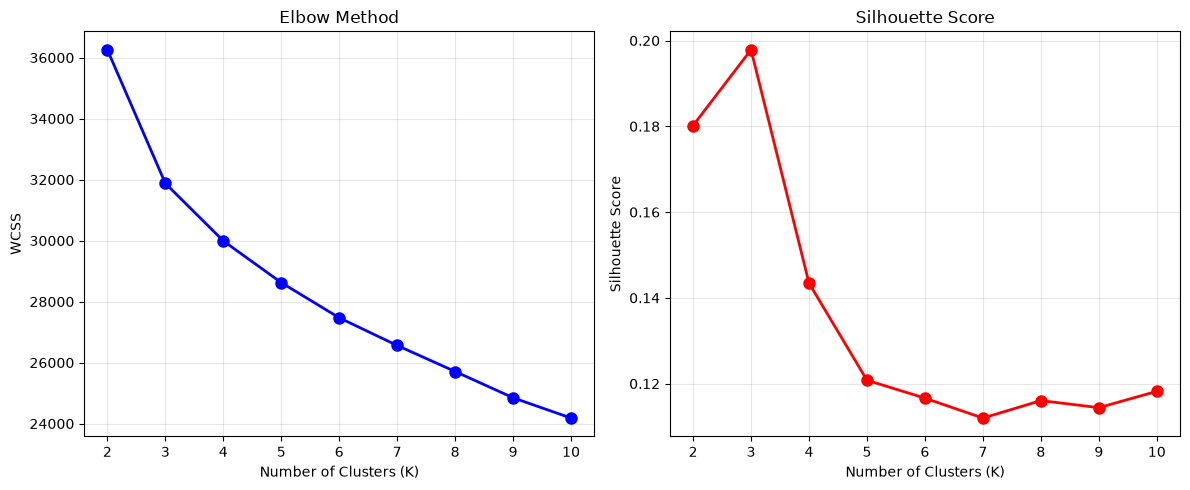

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


wcss = []
silhouette_scores = []
k_range = range(2, 11)  # Silhouette score needs at least 2 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # WCSS
    wcss.append(kmeans.inertia_)

    # Silhouette score
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Create two plots
plt.figure(figsize=(12, 5))

# Elbow plot
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Silhouette plot
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

plt.tight_layout()
plt.show()



# test 2 groups

In [21]:
X_scaled

array([[-0.35280459, -0.92866528,  1.40688327, ...,  1.55940752,
         0.52524053,  0.72581288],
       [-0.35280459, -0.92866528,  1.40688327, ...,  2.69648333,
        -1.55332337,  0.        ],
       [-0.35280459,  1.07681424,  1.40688327, ..., -0.33616111,
        -0.12431069, -0.39867116],
       ...,
       [-0.35280459, -0.92866528, -0.71079102, ..., -0.28873676,
         1.304702  , -0.98325182],
       [-0.35280459,  1.07681424,  1.40688327, ..., -0.3269226 ,
        -0.83881703, -0.69274296],
       [ 2.72774457, -0.92866528,  1.40688327, ..., -0.35648583,
        -1.55332337,  0.        ]], shape=(2017, 22))

In [22]:
df

,gender,married,has_children,age,num_session,num_trips,num_flights,num_hotels,booking_discount_rate,average_seats,...,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer,trips_per_session,total_spent
5,0,False,True,45,11,4,4,4,0.000000,1.0,...,0.000000,3.000000,789.9600,1891.0,23.000000,0.000000,2.863280,8.032746,0.363636,2680.9600
12,0,False,True,26,11,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,21.909091,316.524720,1.844355,11.878996,0.000000,NaN
17,0,True,True,46,12,3,3,1,0.333333,1.0,...,0.000000,5.000000,1450.7475,240.0,13.000000,737.908120,8.020566,1.620833,0.250000,1690.7475
19,0,False,False,20,11,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,12.545455,0.000000,8.038835,1.560606,0.000000,NaN
20,1,True,False,30,11,3,3,3,0.000000,1.0,...,0.666667,1.333333,1802.7900,644.0,12.727273,916.235430,8.007626,1.589394,0.272727,2446.7900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5774,0,False,False,24,8,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,36.500000,795.942662,2.223068,16.418750,0.000000,NaN
5778,0,True,True,44,8,2,2,2,0.000000,1.0,...,1.000000,1.000000,353.3500,291.0,21.625000,263.178203,8.052754,2.685417,0.250000,644.3500
5779,0,False,False,45,8,4,4,1,0.000000,1.0,...,1.000000,4.000000,1039.1700,136.8,14.250000,719.002463,8.000000,1.781250,0.500000,1175.9700
5780,0,True,True,44,8,1,1,1,0.000000,1.0,...,0.000000,6.000000,579.7900,852.0,13.125000,398.104421,7.944515,1.652083,0.125000,1431.7900


In [23]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit_predict(X_scaled)

array([1, 0, 1, ..., 1, 0, 0], shape=(2017,), dtype=int32)

In [24]:
df_raw['group'] = kmeans.fit_predict(X_scaled)

In [25]:
df_raw

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer,trips_per_session,total_spent,group
5,153982,F,False,True,canada,toronto,YKZ,45,2022,Ontario,...,3.000000,789.9600,1891.0,23.000000,0.000000,2.863280,8.032746,0.363636,2680.9600,1
12,228195,F,False,True,usa,los angeles,LAX,26,2022,California,...,NaN,NaN,NaN,21.909091,316.524720,1.844355,11.878996,0.000000,NaN,0
17,298253,F,True,True,usa,los angeles,LAX,46,2022,California,...,5.000000,1450.7475,240.0,13.000000,737.908120,8.020566,1.620833,0.250000,1690.7475,1
19,306165,F,False,False,usa,cleveland,CLE,20,2022,Ohio,...,NaN,NaN,NaN,12.545455,0.000000,8.038835,1.560606,0.000000,NaN,0
20,312488,M,True,False,usa,new york,JFK,30,2022,New York,...,1.333333,1802.7900,644.0,12.727273,916.235430,8.007626,1.589394,0.272727,2446.7900,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5774,770252,F,False,False,usa,oakland,OAK,24,2023,California,...,NaN,NaN,NaN,36.500000,795.942662,2.223068,16.418750,0.000000,NaN,0
5778,785186,F,True,True,usa,little rock,LIT,44,2023,Arkansas,...,1.000000,353.3500,291.0,21.625000,263.178203,8.052754,2.685417,0.250000,644.3500,0
5779,792549,F,False,False,usa,kansas city,MCI,45,2023,Missouri,...,4.000000,1039.1700,136.8,14.250000,719.002463,8.000000,1.781250,0.500000,1175.9700,1
5780,811077,F,True,True,usa,knoxville,TYS,44,2023,Tennessee,...,6.000000,579.7900,852.0,13.125000,398.104421,7.944515,1.652083,0.125000,1431.7900,0


In [26]:
df_raw["group"].value_counts()

group
0    1026
1     991
Name: count, dtype: int64

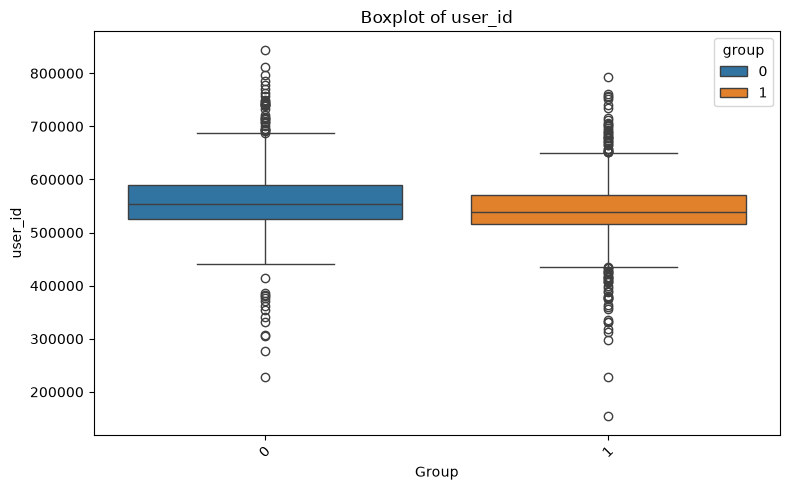

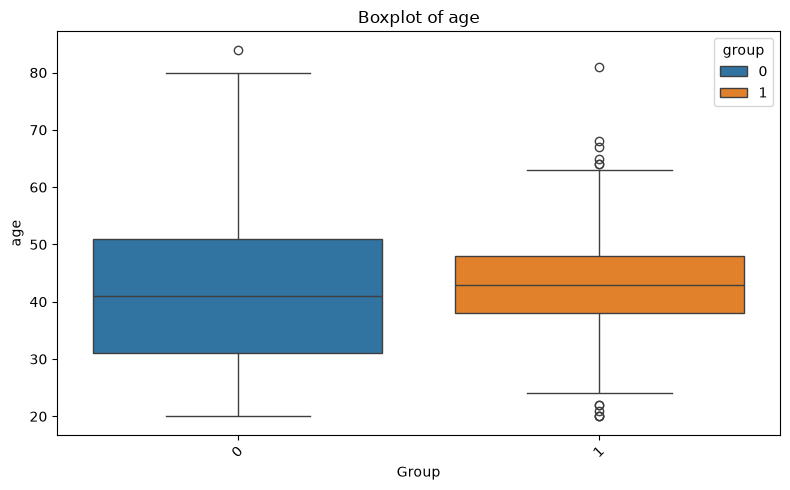

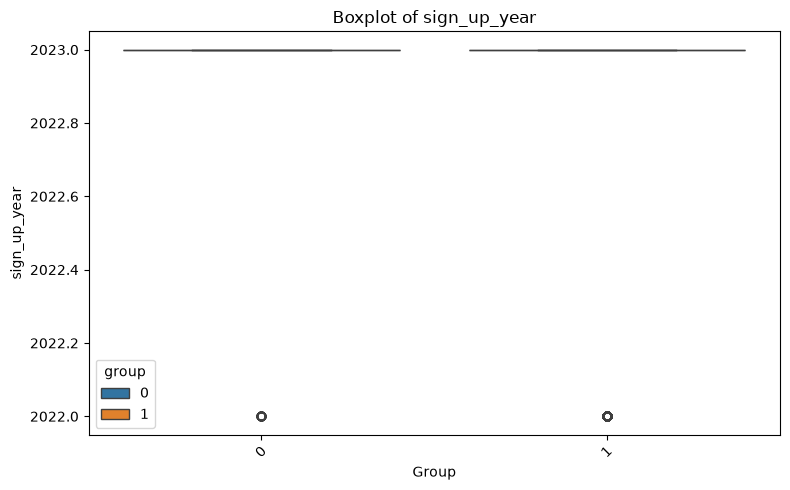

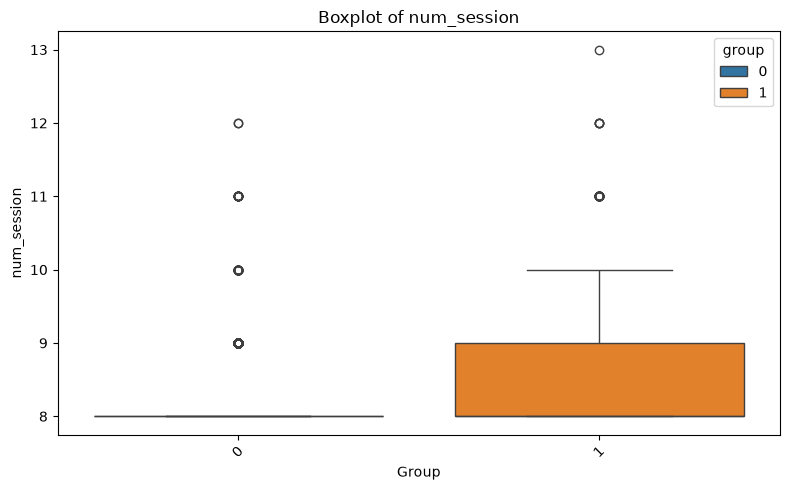

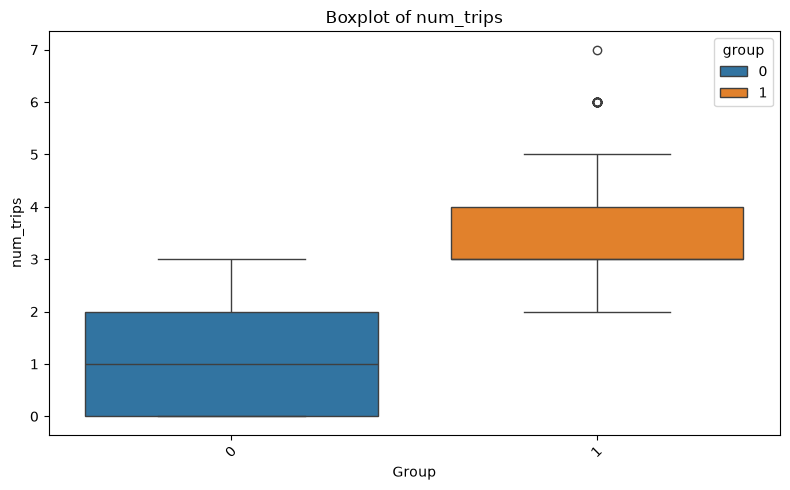

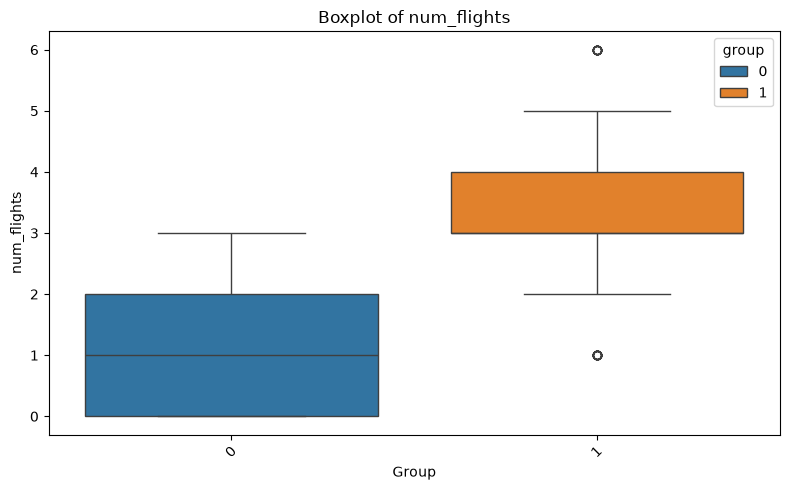

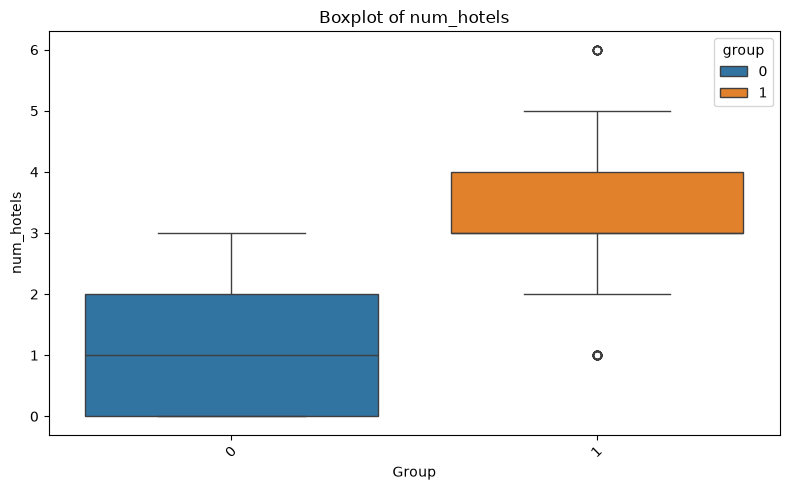

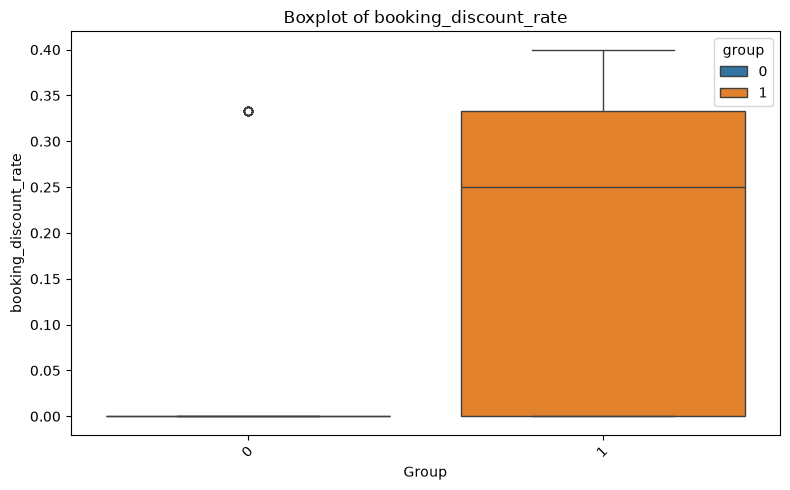

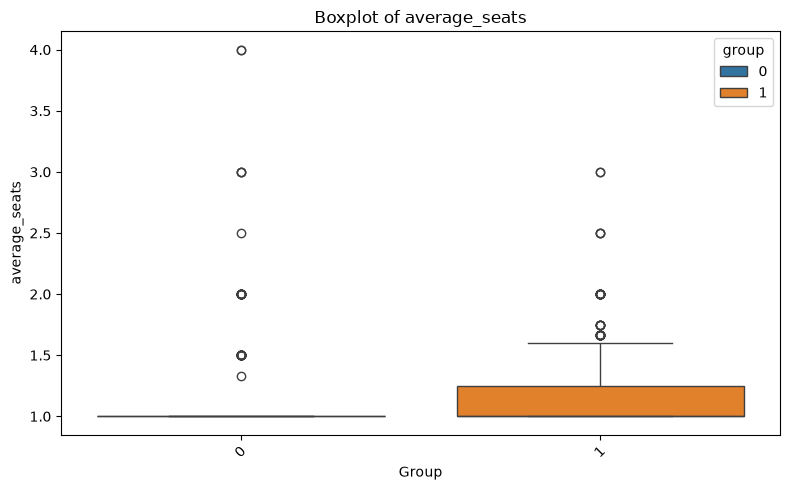

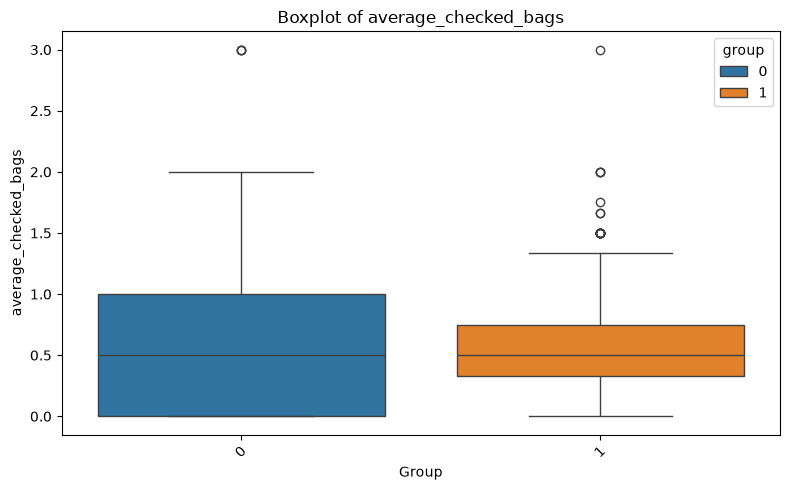

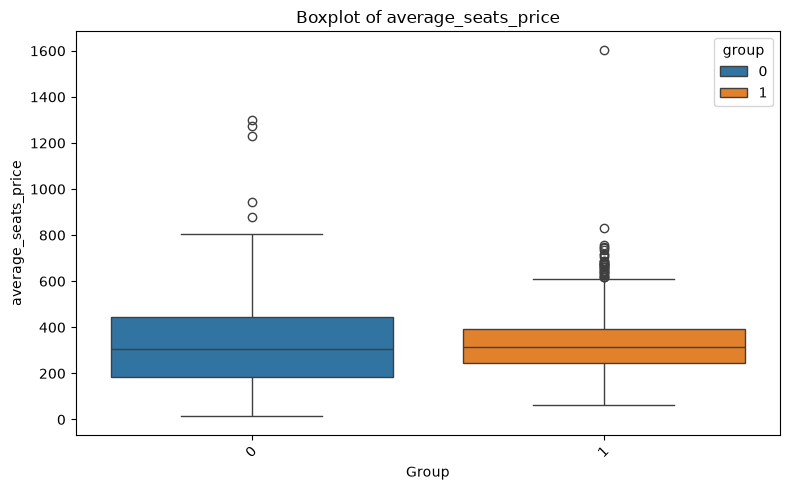

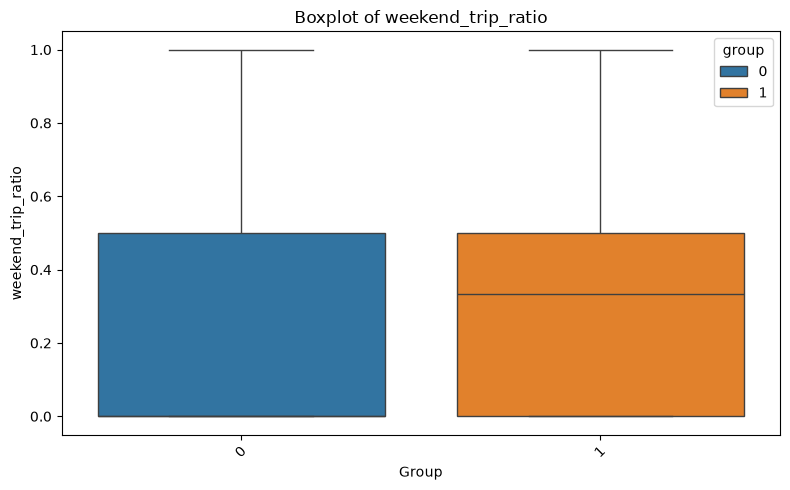

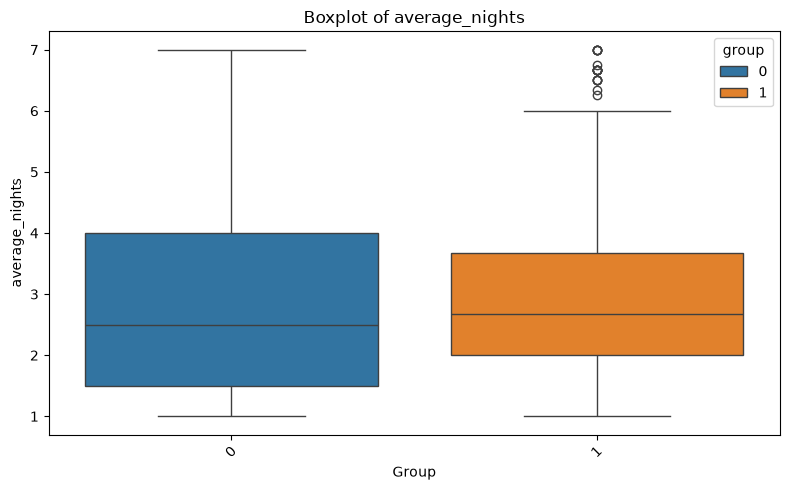

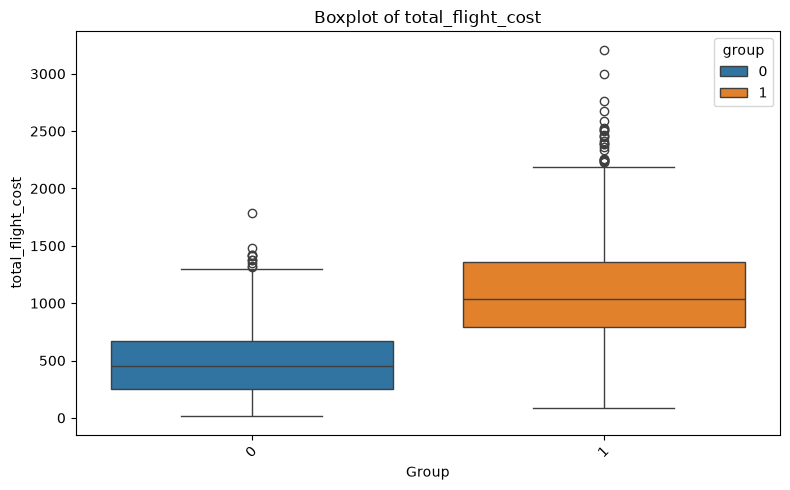

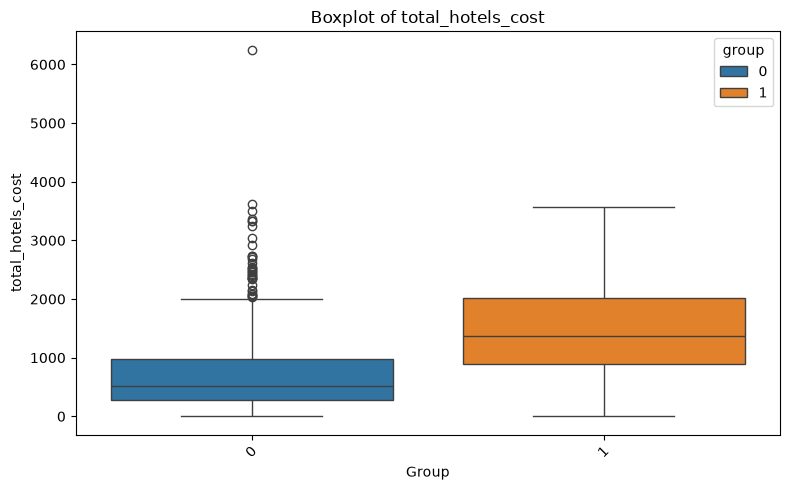

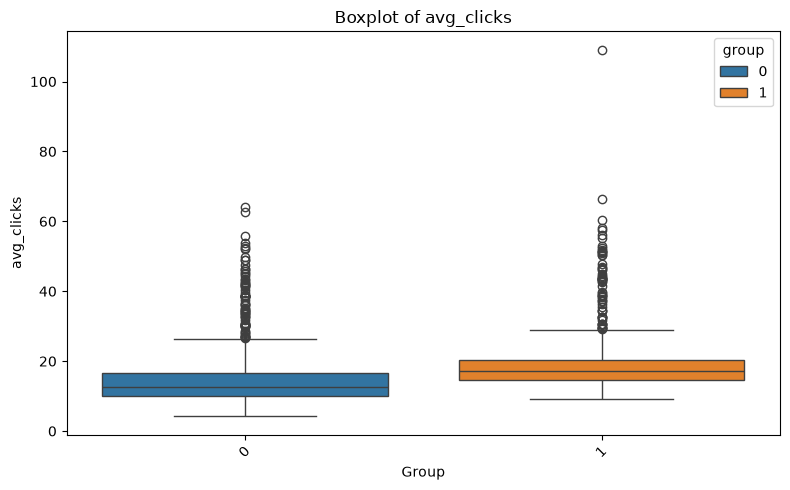

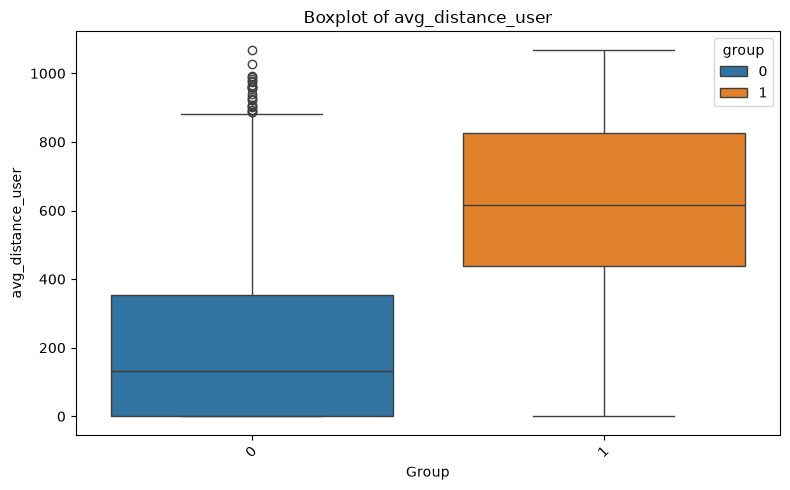

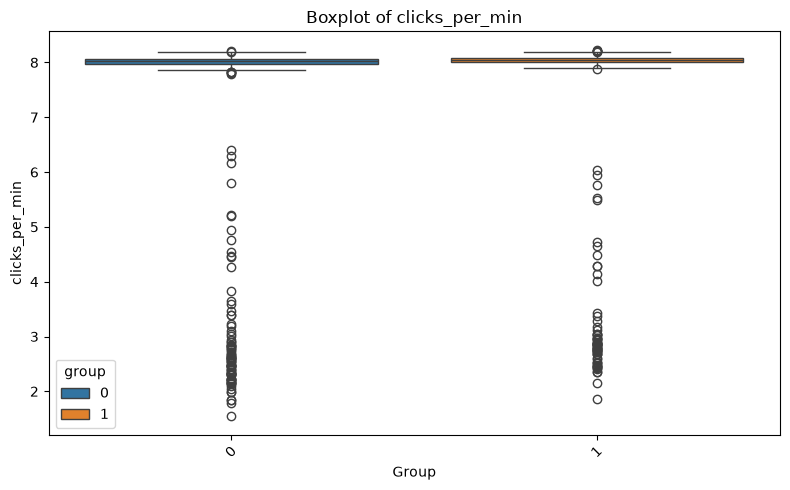

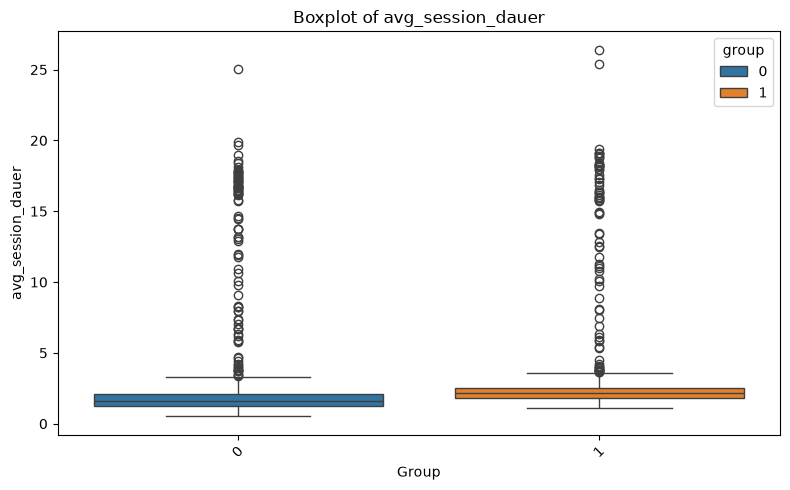

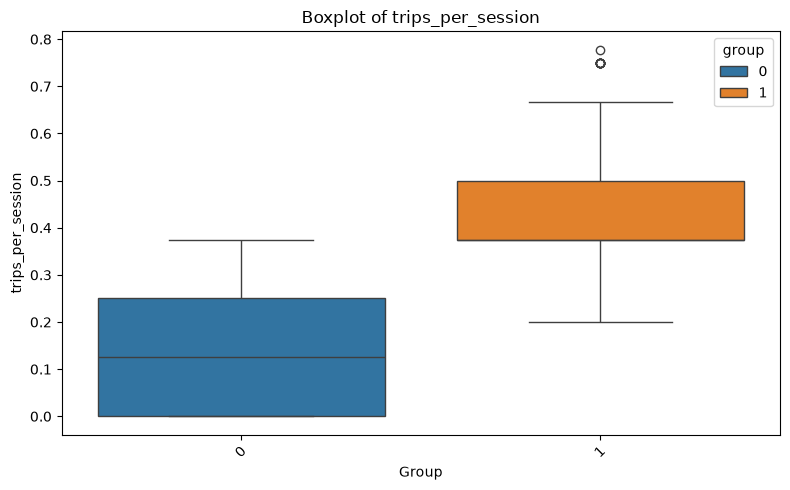

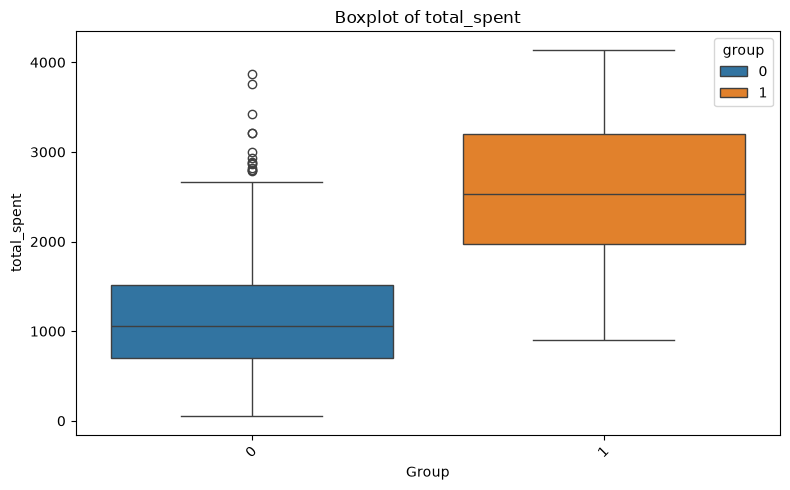

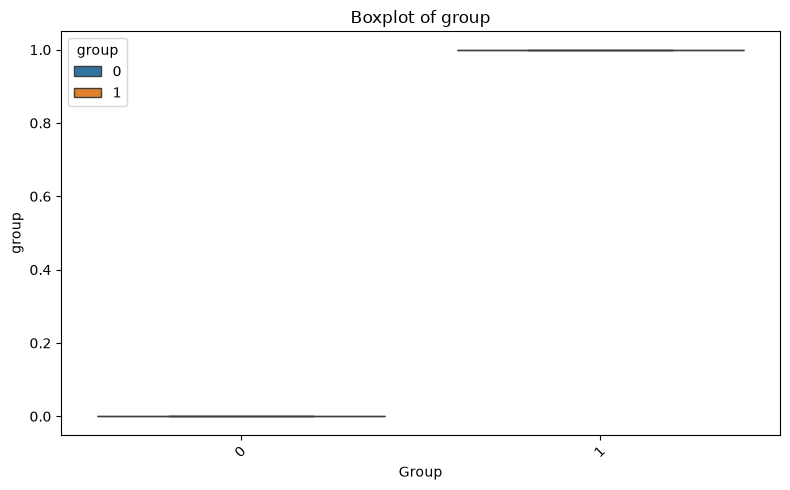

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get numerical columns
num_cols = df_raw.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(data=df_raw, x='group', y=col, hue='group')
    
    plt.title(f'Boxplot of {col}' )
    plt.xlabel('Group')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [28]:
df_raw["group"] = df_raw["group"].map({0:"Budget & Occasional Travelers", 1: "Frequent Travelers"})

In [29]:
df_raw

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer,trips_per_session,total_spent,group
5,153982,F,False,True,canada,toronto,YKZ,45,2022,Ontario,...,3.000000,789.9600,1891.0,23.000000,0.000000,2.863280,8.032746,0.363636,2680.9600,Frequent Travelers
12,228195,F,False,True,usa,los angeles,LAX,26,2022,California,...,NaN,NaN,NaN,21.909091,316.524720,1.844355,11.878996,0.000000,NaN,Budget & Occasional Travelers
17,298253,F,True,True,usa,los angeles,LAX,46,2022,California,...,5.000000,1450.7475,240.0,13.000000,737.908120,8.020566,1.620833,0.250000,1690.7475,Frequent Travelers
19,306165,F,False,False,usa,cleveland,CLE,20,2022,Ohio,...,NaN,NaN,NaN,12.545455,0.000000,8.038835,1.560606,0.000000,NaN,Budget & Occasional Travelers
20,312488,M,True,False,usa,new york,JFK,30,2022,New York,...,1.333333,1802.7900,644.0,12.727273,916.235430,8.007626,1.589394,0.272727,2446.7900,Frequent Travelers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5774,770252,F,False,False,usa,oakland,OAK,24,2023,California,...,NaN,NaN,NaN,36.500000,795.942662,2.223068,16.418750,0.000000,NaN,Budget & Occasional Travelers
5778,785186,F,True,True,usa,little rock,LIT,44,2023,Arkansas,...,1.000000,353.3500,291.0,21.625000,263.178203,8.052754,2.685417,0.250000,644.3500,Budget & Occasional Travelers
5779,792549,F,False,False,usa,kansas city,MCI,45,2023,Missouri,...,4.000000,1039.1700,136.8,14.250000,719.002463,8.000000,1.781250,0.500000,1175.9700,Frequent Travelers
5780,811077,F,True,True,usa,knoxville,TYS,44,2023,Tennessee,...,6.000000,579.7900,852.0,13.125000,398.104421,7.944515,1.652083,0.125000,1431.7900,Budget & Occasional Travelers


In [30]:
df_final = pd.concat([user_features[user_features["group"]!= "Not assigned"], df_raw])

In [31]:
df_final

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer,trips_per_session,total_spent,group
0,94883,F,True,False,usa,kansas city,MCI,51,2022,Missouri,...,1.000000,5354.8600,230.00,8.333333,1060.930335,8.042895,1.036111,0.250000,5584.8600,VIPs
1,101486,F,True,True,usa,tacoma,TCM,50,2022,Washington,...,3.333333,351.7425,2277.05,26.153846,2094.397252,2.379286,10.992308,0.230769,2628.7925,Long-Distance Travelers
2,101961,F,True,False,usa,boston,BOS,43,2022,Massachusetts,...,3.285714,1924.2330,2550.40,18.166667,2436.512974,8.049231,2.256944,0.583333,4474.6330,VIPs
3,106907,F,True,True,usa,miami,TNT,44,2022,Florida,...,6.000000,165.5100,2231.00,26.285714,2061.557769,3.142023,8.365858,0.142857,2396.5100,Long-Distance Travelers
4,118043,F,False,True,usa,los angeles,LAX,51,2022,California,...,5.500000,2339.2900,5811.00,16.153846,623.381115,4.274937,3.778733,0.384615,8150.2900,VIPs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5774,770252,F,False,False,usa,oakland,OAK,24,2023,California,...,NaN,NaN,NaN,36.500000,795.942662,2.223068,16.418750,0.000000,NaN,Budget & Occasional Travelers
5778,785186,F,True,True,usa,little rock,LIT,44,2023,Arkansas,...,1.000000,353.3500,291.00,21.625000,263.178203,8.052754,2.685417,0.250000,644.3500,Budget & Occasional Travelers
5779,792549,F,False,False,usa,kansas city,MCI,45,2023,Missouri,...,4.000000,1039.1700,136.80,14.250000,719.002463,8.000000,1.781250,0.500000,1175.9700,Frequent Travelers
5780,811077,F,True,True,usa,knoxville,TYS,44,2023,Tennessee,...,6.000000,579.7900,852.00,13.125000,398.104421,7.944515,1.652083,0.125000,1431.7900,Budget & Occasional Travelers


# df_final analysis

In [32]:
df_final["group"].value_counts()

group
VIPs                             1200
Budget & Occasional Travelers    1026
Frequent Travelers                991
Long-Distance Travelers           790
Discount buyers                   695
Quick Decision Makers             627
Long Stayers                      230
Young Travelers                   153
Family Travelers                   70
Name: count, dtype: int64

In [33]:
df_final[["user_id", "group"]]

,user_id,group
0,94883,VIPs
1,101486,Long-Distance Travelers
2,101961,VIPs
3,106907,Long-Distance Travelers
4,118043,VIPs
...,...,...
5774,770252,Budget & Occasional Travelers
5778,785186,Budget & Occasional Travelers
5779,792549,Frequent Travelers
5780,811077,Budget & Occasional Travelers


In [34]:
df_final.to_csv("data/final_data_groups/df_final.csv", index=False)